In [58]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [59]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)


In [60]:
df = pd.read_csv('Dataset .csv')  # Make sure filename matches exactly

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Dataset shape: (9551, 21)

First 5 rows:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [37]:
print("Dataset Info:")
print("-" * 40)
df.info()


Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now

In [38]:
print("Statistical Summary:")
print("-" * 40)
df.describe()

Statistical Summary:
----------------------------------------


,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


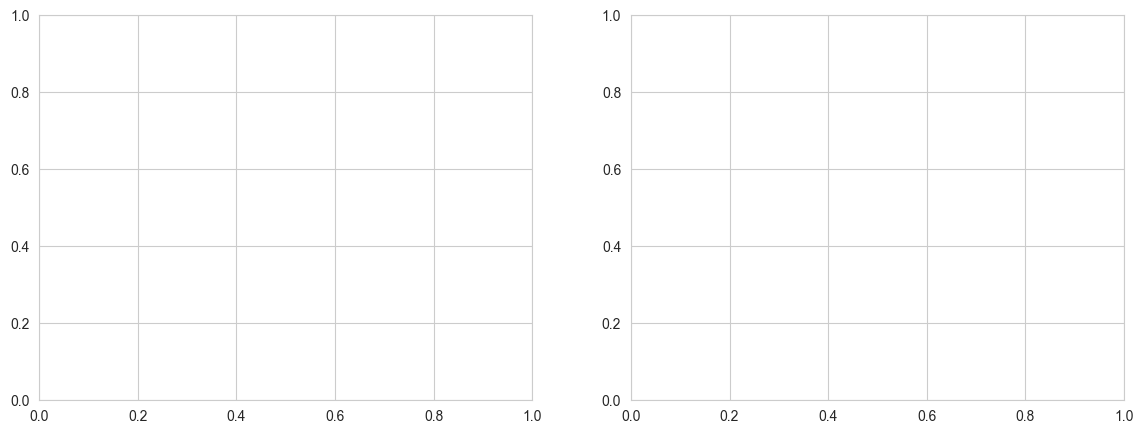

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [40]:
axes[0].hist(df['Aggregate rating'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Restaurant Ratings', fontsize=14)
axes[0].set_xlabel('Aggregate Rating')
axes[0].set_ylabel('Frequency')


Text(4.444444444444452, 0.5, 'Frequency')

In [41]:
sns.boxplot(data=df, y='Aggregate rating', ax=axes[1])
axes[1].set_title('Box Plot of Ratings', fontsize=14)
axes[1].set_ylabel('Aggregate Rating')

Text(596.2626262626262, 0.5, 'Aggregate Rating')

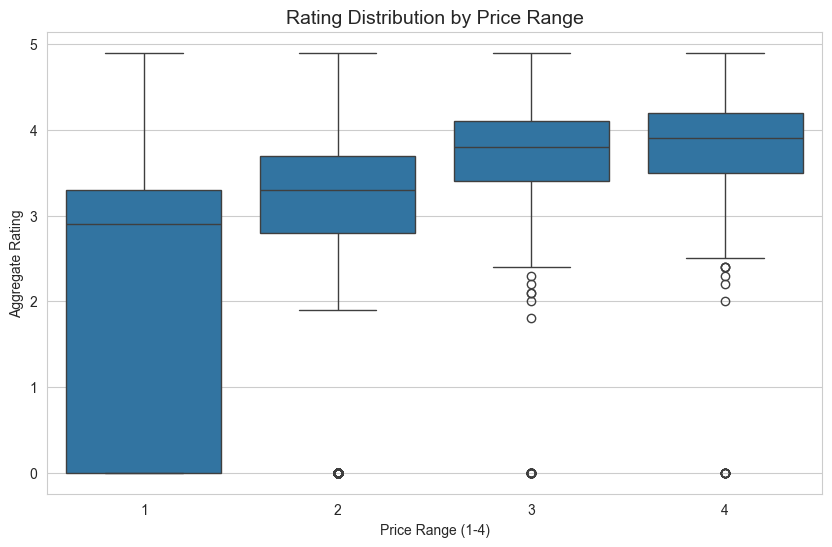

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Price range', y='Aggregate rating')
plt.title('Rating Distribution by Price Range', fontsize=14)
plt.xlabel('Price Range (1-4)')
plt.ylabel('Aggregate Rating')
plt.show()

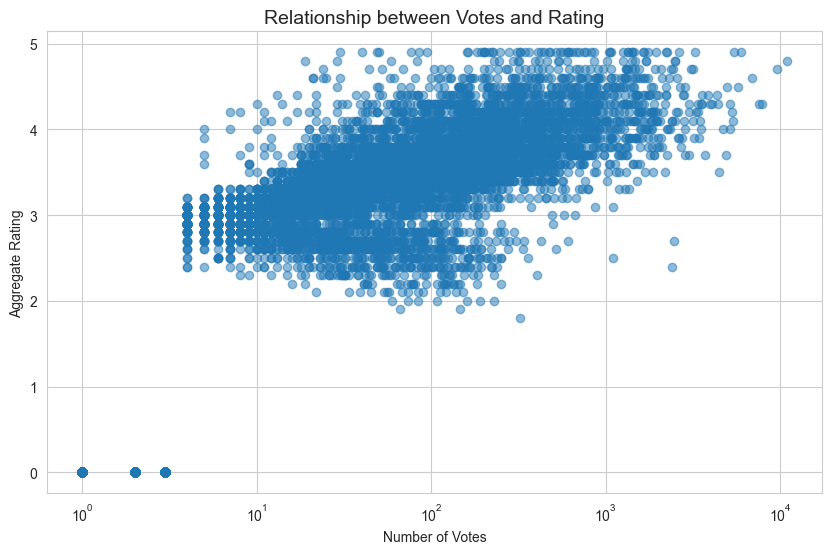

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Votes'], df['Aggregate rating'], alpha=0.5)
plt.title('Relationship between Votes and Rating', fontsize=14)
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')
plt.xscale('log')  # Log scale for better visualization
plt.show()


In [44]:


df['Main_Cuisine'] = df['Cuisines'].str.split(',').str[0].str.strip()

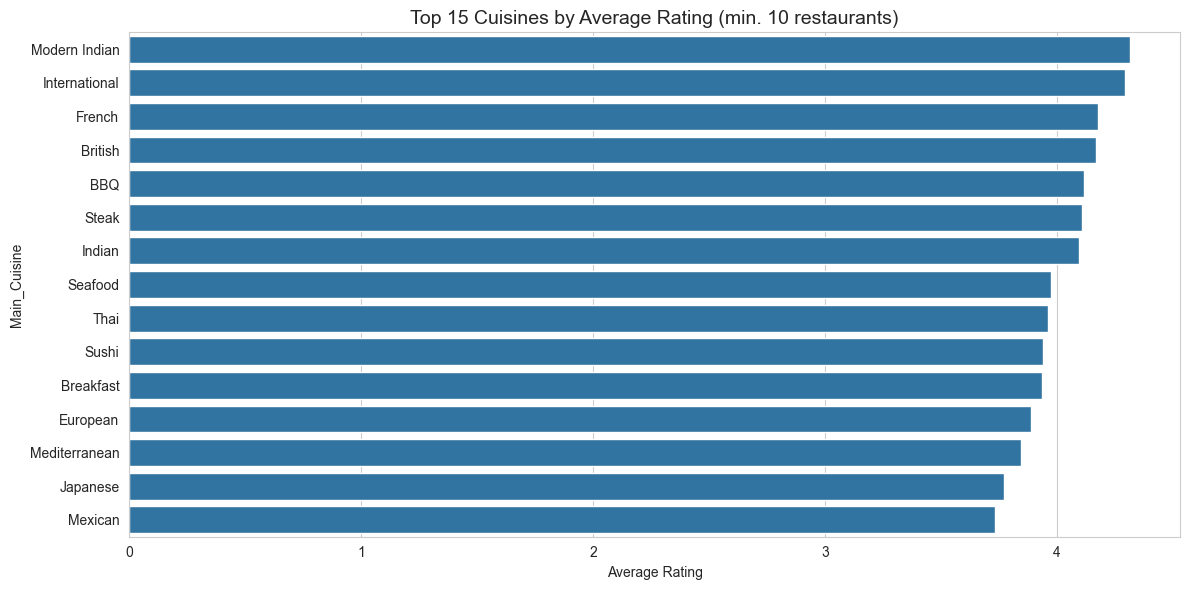

In [45]:
cuisine_ratings = df.groupby('Main_Cuisine')['Aggregate rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_cuisines = cuisine_ratings[cuisine_ratings['count'] > 10].head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cuisines.reset_index(), x='mean', y='Main_Cuisine')
plt.title('Top 15 Cuisines by Average Rating (min. 10 restaurants)', fontsize=14)
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

In [46]:
print("Data Cleaning Steps:")
print("-" * 40)

Data Cleaning Steps:
----------------------------------------


In [47]:
initial_count = len(df)
df_clean = df[df['Aggregate rating'] > 0].copy()
print(f"✓ Removed {initial_count - len(df_clean)} restaurants with 0 rating")
print(f"  New dataset size: {len(df_clean)}")

✓ Removed 2148 restaurants with 0 rating
  New dataset size: 7403


In [48]:
print(f"\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


Remaining missing values:
Cuisines        9
Main_Cuisine    9
dtype: int64


In [49]:
print("Feature Engineering:")
print("-" * 40)

Feature Engineering:
----------------------------------------


In [50]:
binary_columns = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_columns:
    df_clean[col + '_Binary'] = df_clean[col].map({'Yes': 1, 'No': 0})
    print(f"✓ Created {col}_Binary")

✓ Created Has Table booking_Binary
✓ Created Has Online delivery_Binary
✓ Created Is delivering now_Binary
✓ Created Switch to order menu_Binary


In [51]:
df_clean['Log_Votes'] = np.log1p(df_clean['Votes'])
print("✓ Created Log_Votes (log-transformed)")


✓ Created Log_Votes (log-transformed)


In [52]:
df_clean['Cost_per_person'] = df_clean['Average Cost for two'] / 2
print("✓ Created Cost_per_person")

✓ Created Cost_per_person


In [ ]:
# %% [code]
# Model 1: Linear Regression
print("=" * 50)
print("LINEAR REGRESSION")
print("=" * 50)

lr_model, lr_metrics, lr_pred = evaluate_model(
    LinearRegression(), "Linear Regression", X_train, X_test, y_train, y_test
)

results['Linear Regression'] = lr_metrics
predictions['Linear Regression'] = lr_pred

print(f"Training MAE: {lr_metrics['Train MAE']:.4f}")
print(f"Testing MAE: {lr_metrics['Test MAE']:.4f}")
print(f"Training R²: {lr_metrics['Train R²']:.4f}")
print(f"Testing R²: {lr_metrics['Test R²']:.4f}")

# %% [code]
# Model 2: Decision Tree
print("=" * 50)
print("DECISION TREE")
print("=" * 50)

dt_model, dt_metrics, dt_pred = evaluate_model(
    DecisionTreeRegressor(random_state=42, max_depth=10), 
    "Decision Tree", X_train, X_test, y_train, y_test
)

results['Decision Tree'] = dt_metrics
predictions['Decision Tree'] = dt_pred

print(f"Training MAE: {dt_metrics['Train MAE']:.4f}")
print(f"Testing MAE: {dt_metrics['Test MAE']:.4f}")
print(f"Training R²: {dt_metrics['Train R²']:.4f}")
print(f"Testing R²: {dt_metrics['Test R²']:.4f}")


LINEAR REGRESSION
Training MAE: 0.2766
Testing MAE: 0.2726
Training R²: 0.5370
Testing R²: 0.5682
DECISION TREE
Training MAE: 0.2237
Testing MAE: 0.2811
Training R²: 0.6733
Testing R²: 0.5282


In [ ]:
# %% [code]
# Model 3: Random Forest
print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

rf_model, rf_metrics, rf_pred = evaluate_model(
    RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15),
    "Random Forest", X_train, X_test, y_train, y_test
)

results['Random Forest'] = rf_metrics
predictions['Random Forest'] = rf_pred

print(f"Training MAE: {rf_metrics['Train MAE']:.4f}")
print(f"Testing MAE: {rf_metrics['Test MAE']:.4f}")
print(f"Training R²: {rf_metrics['Train R²']:.4f}")
print(f"Testing R²: {rf_metrics['Test R²']:.4f}")


RANDOM FOREST
Training MAE: 0.1647
Testing MAE: 0.2674
Training R²: 0.8357
Testing R²: 0.5802


In [ ]:
if 'best_model_name' in locals():
    print(f"Best model: {best_model_name}")
else:
    print("Variable not defined yet")

Best model: Random Forest


In [55]:
# %% [code]
# Complete GridSearch for Random Forest with all imports

# Import required libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import joblib

In [56]:
best_model_name = 'Random Forest'

In [57]:
if best_model_name == 'Random Forest':
    print("=" * 50)
    print("PERFORMING GRID SEARCH FOR RANDOM FOREST")
    print("=" * 50)

PERFORMING GRID SEARCH FOR RANDOM FOREST


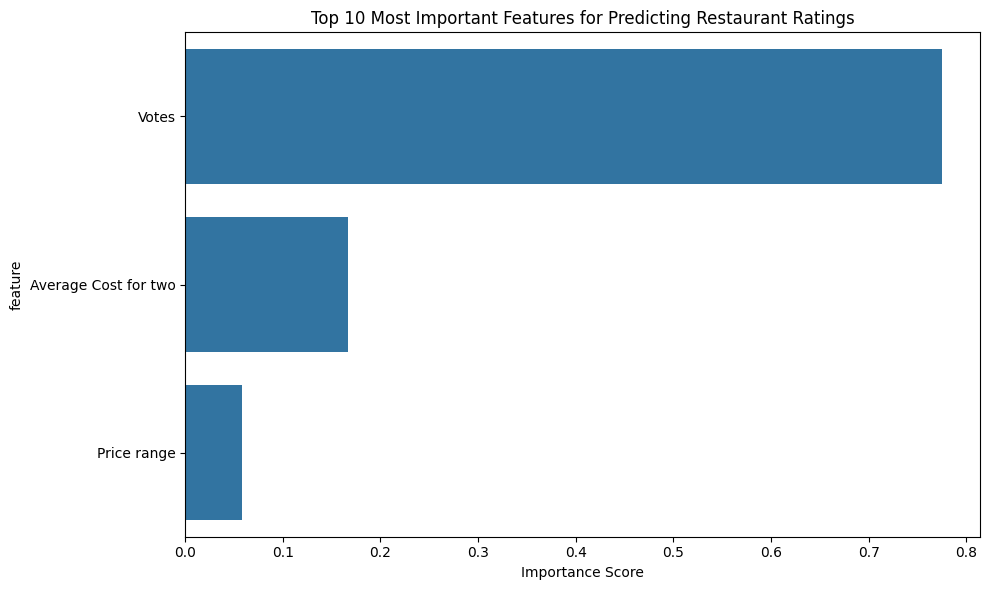


Top 5 Most Important Features:
             feature  importance
               Votes    0.775271
Average Cost for two    0.166843
         Price range    0.057886


In [ ]:

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the saved model
best_model = joblib.load('best_random_forest.pkl')

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features for Predicting Restaurant Ratings')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head(5).to_string(index=False))

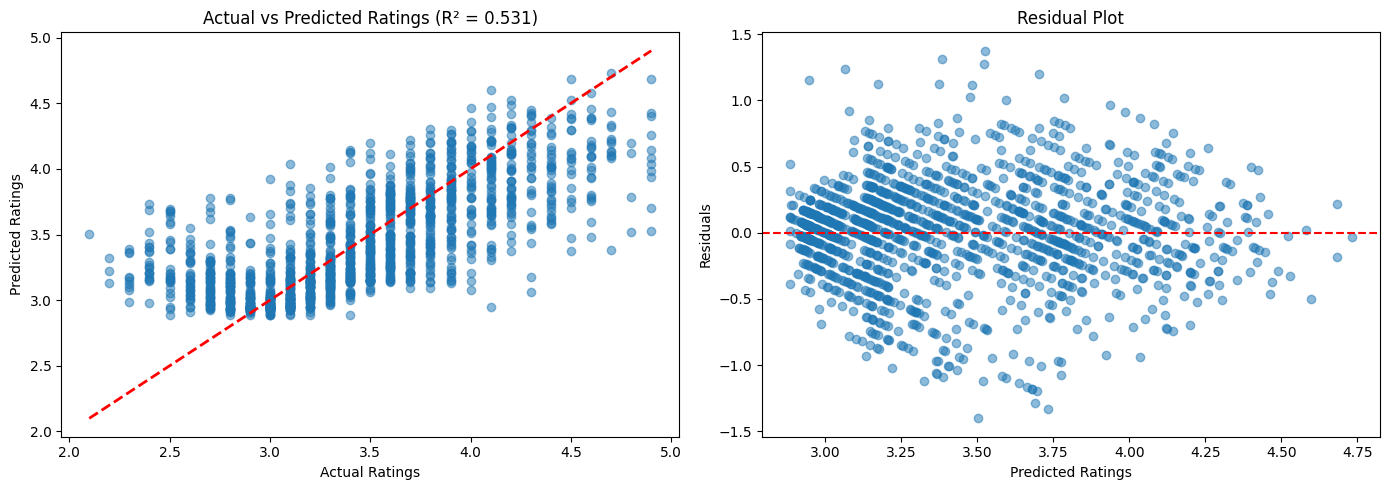

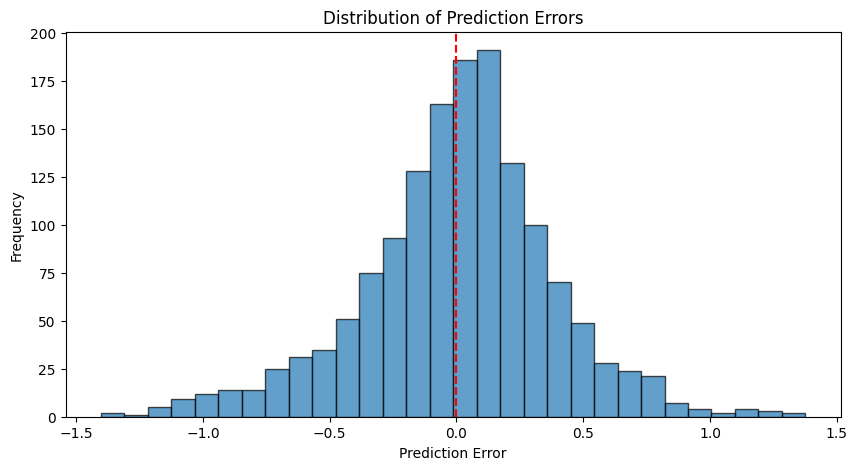

Mean Absolute Error: 0.284
Root Mean Square Error: 0.381


In [ ]:
# %% [code]
# Visualize actual vs predicted ratings
# Make predictions on test set
y_pred = best_model.predict(X_test)

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter plot
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Ratings')
axes[0].set_ylabel('Predicted Ratings')
axes[0].set_title(f'Actual vs Predicted Ratings (R² = {r2_score(y_test, y_pred):.3f})')

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Ratings')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

# Distribution of errors
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Root Mean Square Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")